In [1]:
import pandas as pd
from sklearn.datasets import load_digits
import seaborn as sns 

In [2]:
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [3]:
dataset.data.shape

(1797, 64)

In [4]:
dataset.data[0].reshape(8,8)

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

<Figure size 640x480 with 0 Axes>

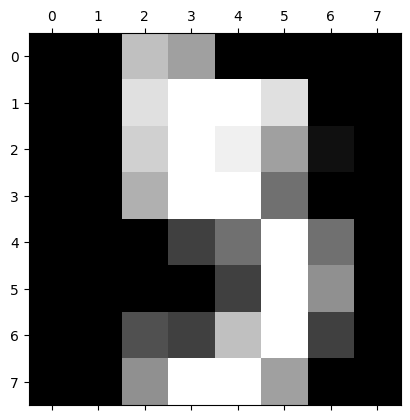

In [5]:
from matplotlib import pyplot as plt
%matplotlib inline

plt.gray()
plt.matshow(dataset.data[5].reshape(8,8))

In [6]:
import numpy as np
np.unique(dataset.target)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [7]:
df = pd.DataFrame(dataset.data,columns=dataset.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [8]:
X=df
y=dataset.target

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_Scaled = scaler.fit_transform(X)
X_Scaled

array([[ 0.        , -0.33501649, -0.04308102, ..., -1.14664746,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  0.54856067,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -1.09493684, ...,  1.56568555,
         1.6951369 , -0.19600752],
       ...,
       [ 0.        , -0.33501649, -0.88456568, ..., -0.12952258,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649, -0.67419451, ...,  0.8876023 ,
        -0.5056698 , -0.19600752],
       [ 0.        , -0.33501649,  1.00877481, ...,  0.8876023 ,
        -0.26113572, -0.19600752]], shape=(1797, 64))

In [10]:
#traintestsplit
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X_Scaled,y,test_size=0.2,random_state=30)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
model.score(X_test,y_test)

0.9722222222222222

In [13]:
#do pca
from sklearn.decomposition import PCA
pca = PCA(0.95)
X_pca=pca.fit_transform(X_Scaled,y)
X_pca.shape

(1797, 40)

In [14]:
pca.explained_variance_ratio_

array([0.12033916, 0.09561054, 0.08444415, 0.06498408, 0.04860155,
       0.0421412 , 0.03942083, 0.03389381, 0.02998221, 0.02932003,
       0.02781805, 0.02577055, 0.02275303, 0.0222718 , 0.02165229,
       0.01914167, 0.01775547, 0.01638069, 0.0159646 , 0.01489191,
       0.0134797 , 0.01271931, 0.01165837, 0.01057647, 0.00975316,
       0.00944559, 0.00863014, 0.00836643, 0.00797693, 0.00746471,
       0.00725582, 0.00691911, 0.00653909, 0.00640793, 0.00591384,
       0.00571162, 0.00523637, 0.00481808, 0.00453719, 0.00423163])

In [15]:
pca.singular_values_ 

array([114.85302699, 102.37451345,  96.21078044,  84.39999879,
        72.99010872,  67.96610756,  65.73578102,  60.95356994,
        57.32852629,  56.69191509,  55.22075421,  53.14969878,
        49.94115773,  49.41019748,  48.71816444,  45.80668083,
        44.1169066 ,  42.37454892,  41.83290264,  40.40305315,
        38.43961237,  37.33969751,  35.74850946,  34.04938284,
        32.69727943,  32.17758891,  30.7572734 ,  30.28370514,
        29.57038059,  28.60523593,  28.20215217,  27.54001362,
        26.77302597,  26.50316199,  25.46090183,  25.02181236,
        23.95819181,  22.98136249,  22.3014224 ,  21.5373702 ])

In [16]:
X_train_pca, X_test_pca, y_train_pca,y_test_pca = train_test_split(X_pca,y,test_size=0.2,random_state=30)

In [17]:
model2 = LogisticRegression()
model2.fit(X_train_pca,y_train_pca)
model2.score(X_test_pca,y_test_pca)

0.9638888888888889

## Ass Heart disease Classification

In [18]:
df_ht=pd.read_csv('Datasets/heart.csv')
df_ht.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [19]:
df_ht.shape

(918, 12)

In [20]:
df_ht.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [21]:
df_ht.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [22]:
df_ht.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [23]:
df_ht.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

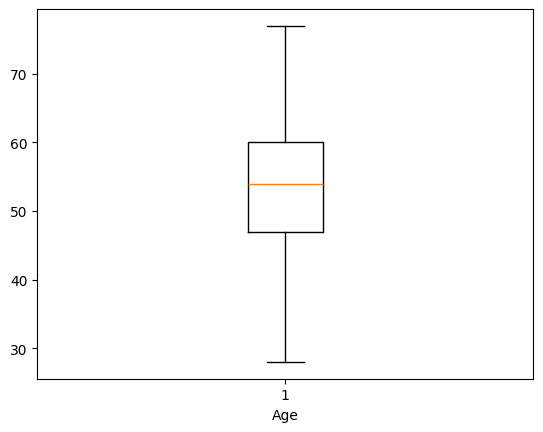

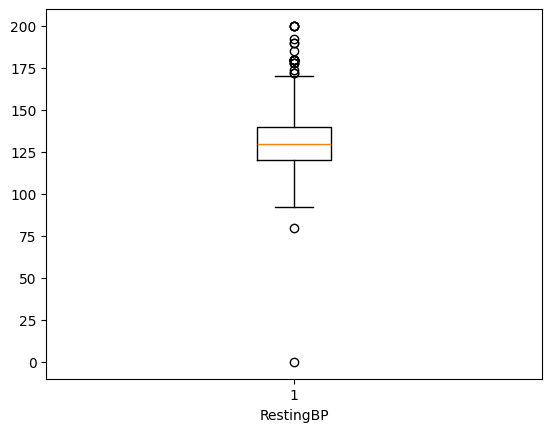

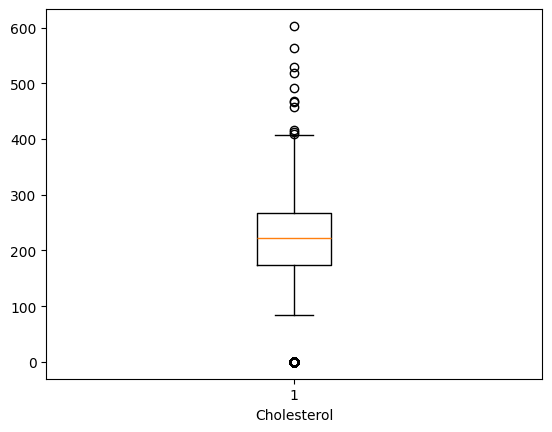

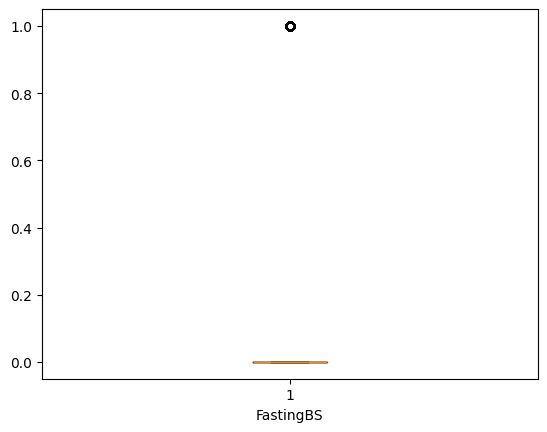

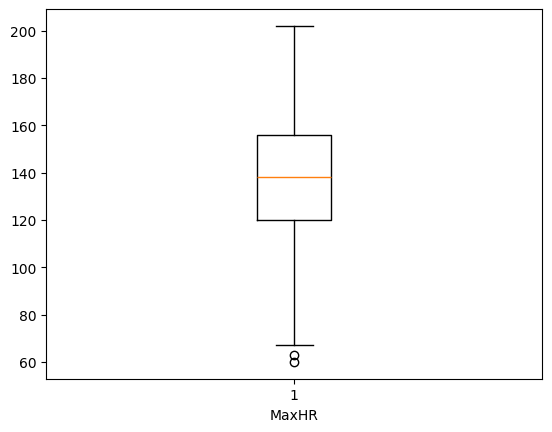

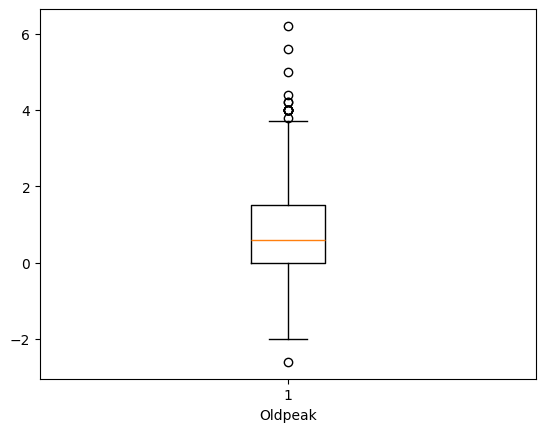

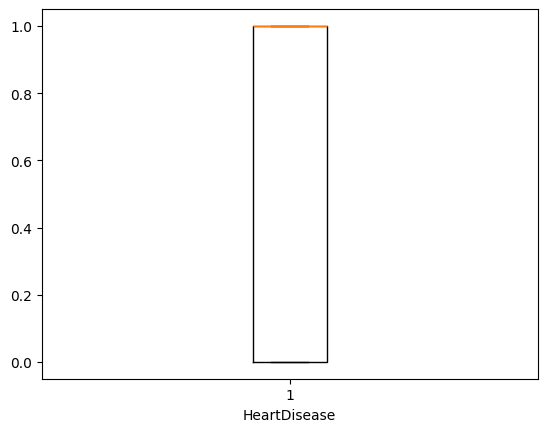

In [24]:
for col in df_ht.columns:
    if pd.api.types.is_numeric_dtype(df_ht[col]):
        plt.boxplot(df_ht[col])
        plt.xlabel(f'{col}')
        plt.show()

In [25]:
def drop_outliers(col,df):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3-q1
    df=df[(df[col]>=q1-1.5*iqr)&(df[col]<=q3+1.5*iqr)]
    plt.boxplot(df[col])
    plt.xlabel(f'{col}')
    plt.show()
    return df

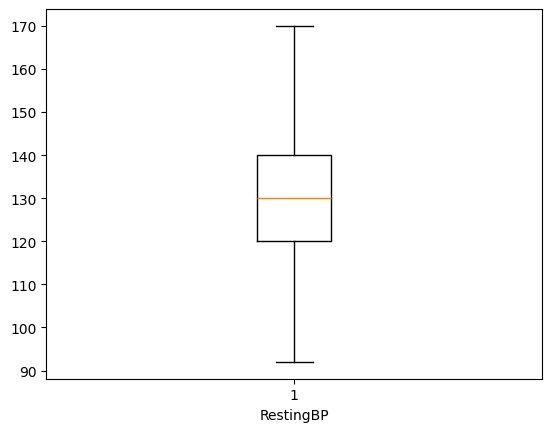

<Axes: xlabel='RestingBP', ylabel='Count'>

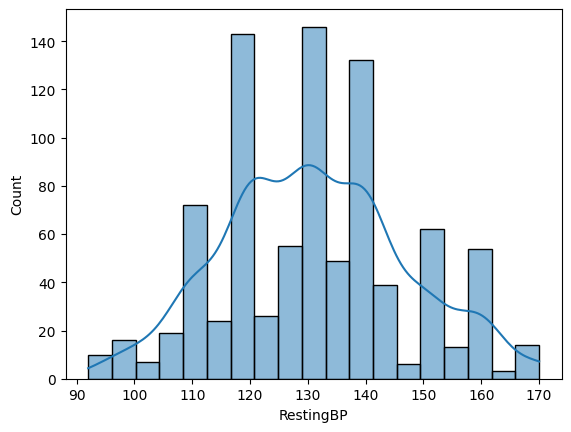

In [26]:
df_ht=drop_outliers('RestingBP',df_ht)
sns.histplot(df_ht['RestingBP'],kde=True)

In [27]:
df_ht.shape

(890, 12)

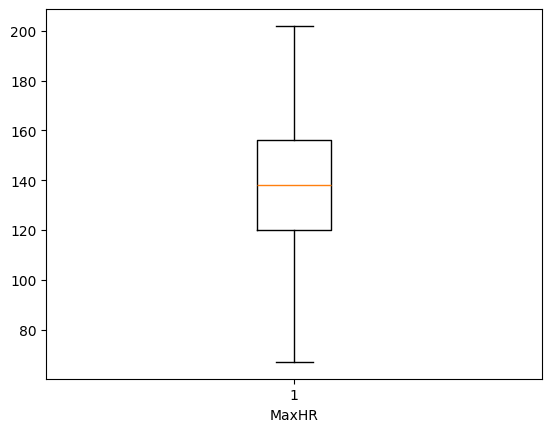

<Axes: xlabel='MaxHR', ylabel='Count'>

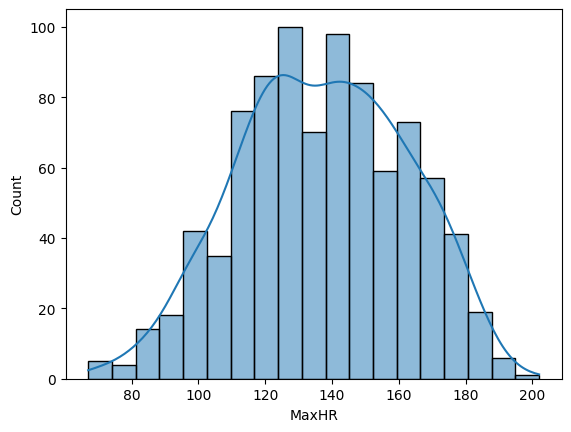

In [28]:
df_ht=drop_outliers('MaxHR',df_ht)
sns.histplot(df_ht['MaxHR'],kde=True)

In [29]:
df_ht.shape

(888, 12)

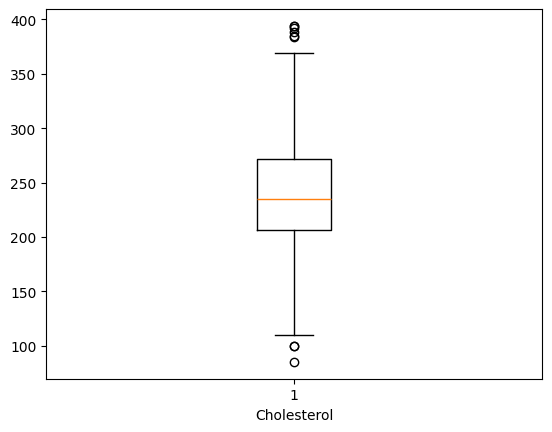

<Axes: xlabel='Cholesterol', ylabel='Count'>

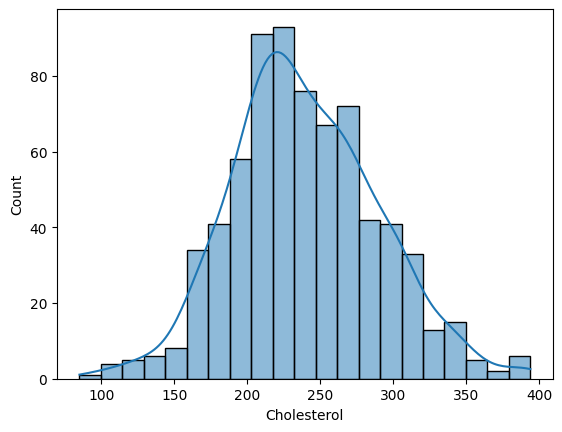

In [30]:
df_ht=drop_outliers('Cholesterol',df_ht)
sns.histplot(df_ht['Cholesterol'],kde=True)

In [31]:
df_ht.shape

(713, 12)

In [32]:
df_ht.Cholesterol.describe()

count    713.000000
mean     239.586255
std       50.221797
min       85.000000
25%      206.000000
50%      235.000000
75%      272.000000
max      394.000000
Name: Cholesterol, dtype: float64

In [33]:
df_ht[df_ht.Cholesterol==0].value_counts()

Series([], Name: count, dtype: int64)

<Axes: xlabel='Oldpeak', ylabel='Count'>

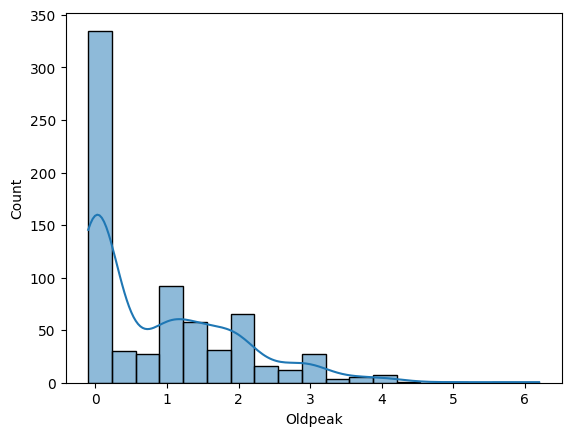

In [34]:
#df_ht=drop_outliers('Oldpeak',df_ht)
import seaborn as sns 
sns.histplot(df_ht['Oldpeak'],kde=True)

In [35]:
df_ht.Oldpeak.describe()

count    713.000000
mean       0.889902
std        1.062610
min       -0.100000
25%        0.000000
50%        0.500000
75%        1.500000
max        6.200000
Name: Oldpeak, dtype: float64

In [36]:
df_enc = pd.get_dummies(df_ht, drop_first=True,dtype=int)
df_enc.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1.5,1,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0.0,0,1,0,1,0,1,0,0,0,1


In [37]:
df_enc.shape

(713, 16)

In [38]:
X=df_enc.drop('HeartDisease',axis=1)
y=df_enc.HeartDisease

In [39]:
X_scaled=scaler.fit_transform(X)
X_scaled

array([[-1.34159781,  0.54157996,  0.98460104, ..., -0.78535345,
        -0.94140501,  1.05035462],
       [-0.39886532,  1.83889733, -1.18729494, ..., -0.78535345,
         1.06224207, -0.95205941],
       [-1.65584198, -0.10707872,  0.86504713, ..., -0.78535345,
        -0.94140501,  1.05035462],
       ...,
       [ 0.43911913, -0.10707872, -2.16365184, ...,  1.27331203,
         1.06224207, -0.95205941],
       [ 0.43911913, -0.10707872, -0.07145847, ..., -0.78535345,
         1.06224207, -0.95205941],
       [-1.55109392,  0.41184823, -1.28692319, ..., -0.78535345,
        -0.94140501,  1.05035462]], shape=(713, 15))

In [40]:
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier

In [41]:
model_params={
    'svm':{
        'model':svm.SVC(gamma='auto'),
        'params':{
            'C':[1,2,5,7,10,],
            'kernel':['rbf','linear']
        }
    },
    'random_forest':{
        'model':RandomForestClassifier(),
        'params':{
            'n_estimators':[5,10,20,30,50,70]
        }
    },
    'logistic_regression':{
        'model':LogisticRegression(multi_class='auto',max_iter=200),
        'params':{
            'C':[1,2,5,10],
            'solver':['newton-cg','lbfgs']
        }
    }
}

In [42]:
from sklearn.model_selection import GridSearchCV

In [43]:
scores=[]
for model_name,np in model_params.items():
    clf=GridSearchCV(estimator=np['model'],param_grid=np['params'],cv=6)
    clf.fit(X_scaled,y)
    scores.append({
        'model':model_name,
        'best_score':clf.best_score_,
        'best_param':clf.best_params_
    })
    

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\

In [44]:
df_scores=pd.DataFrame(scores)
df_scores

,model,best_score,best_param
0,svm,0.861036,"{'C': 1, 'kernel': 'rbf'}"
1,random_forest,0.855398,{'n_estimators': 50}
2,logistic_regression,0.862484,"{'C': 2, 'solver': 'newton-cg'}"


In [45]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=24)
model=LogisticRegression(C=2,solver='newton-cg')
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [46]:
model.score(X_test,y_test)

0.9370629370629371

In [47]:
y_pred=model.predict(X_test)

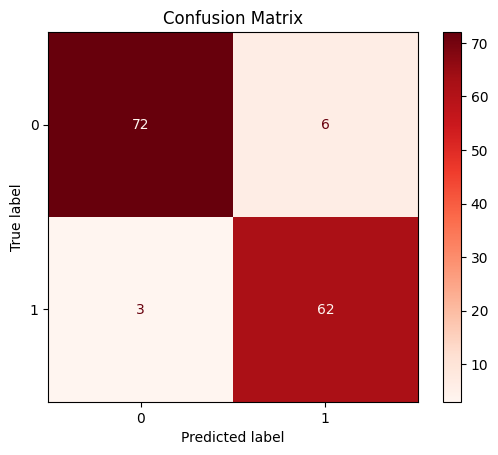

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

# Display it
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title('Confusion Matrix')
plt.show()

In [49]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)
model_rf.score(X_test, y_test)

0.9020979020979021

In [53]:
from sklearn.decomposition import PCA
pca = PCA(0.90)
X_pca=pca.fit_transform(X_scaled,y)
X_pca

array([[ 2.69866005,  0.30443771, -1.60935323, ...,  0.69126543,
        -0.51621228,  0.21390285],
       [ 0.03282374,  1.04719883,  2.05534563, ...,  2.60463674,
        -0.75736136, -0.10599751],
       [ 1.26213186, -2.13680065, -1.92569055, ..., -0.41381184,
        -1.67753847, -0.63232082],
       ...,
       [-1.76623324,  1.6015235 ,  0.06940605, ...,  0.2989946 ,
        -0.04282109, -0.2344663 ],
       [ 0.77578931, -0.30381638, -1.05550163, ...,  1.12009613,
        -0.09264636,  1.64744869],
       [ 2.48521779,  0.62758172,  2.06472491, ...,  1.19343474,
        -0.34270382, -0.41930402]], shape=(713, 11))

In [62]:
X_pca_train,X_pca_test,y_train,y_test=train_test_split(X_pca,y,test_size=0.2,random_state=24)

In [55]:
model_rf = RandomForestClassifier()
model_rf.fit(X_pca_train, y_train)
model_rf.score(X_pca_test, y_test)

0.916083916083916

In [58]:
pca.explained_variance_ratio_

array([0.24060048, 0.10830845, 0.08659793, 0.07819877, 0.07420304,
       0.07132   , 0.05921231, 0.05886169, 0.05283096, 0.04339233,
       0.04073663])

In [59]:
pca.singular_values_

array([50.72693721, 34.03467163, 30.43295745, 28.91947162, 28.1709332 ,
       27.61824308, 25.16496839, 25.09035297, 23.77029898, 21.54253881,
       20.87290647])

In [66]:
model=LogisticRegression(C=2,solver='newton-cg')
model.fit(X_pca_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,2
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'
,max_iter,100
,multi_class,'deprecated'


In [67]:
model.score(X_pca_test,y_test)

0.9230769230769231